In [4]:
import pandas as pd
import numpy as np
import vectorbt as vbt

In [5]:
# 准备数据
market = pd.read_parquet("data_ohlcv.parquet")
f_mev = pd.read_parquet("factors_mev.parquet")
f_ohlcv = pd.read_parquet("factors_ohlcv.parquet")
f_ohlcv = f_ohlcv.fillna(0)
factors = pd.concat([f_mev, f_ohlcv], axis=1, join='outer')

## 1. 测量IC 

In [6]:
def analyze_factor_ic(factor_df, price_series, forward_window):
    """
    计算因子与未来 N 期收益率的 Rank IC
    forward_window: 如果是 5min 数据，12 代表预测未来 1 小时
    """
    # 计算未来收益率 (Forward Returns)
    # vbt 逻辑：shift(-N) 将未来的收益移动到当前行，以便计算 correlation
    forward_returns = price_series.vbt.returns().obj.shift(-forward_window)
    ic_results = {}
    for col in factor_df.columns:
        # 计算 Rank IC (Spearman 相关系数)
        ic = factor_df[col].corr(forward_returns, method='spearman')
        ic_results[col] = ic
        
    return pd.Series(ic_results)

In [7]:
ic_series = analyze_factor_ic(factors, market['close'], 1)
print(ic_series)

f_sandwich_intensity_z    0.103527
f_mev_vol_share_z        -0.273309
f_attack_eff_z           -0.186108
roc_6                    -0.003519
roc_12                   -0.002682
roc_48                   -0.001080
madev_6                  -0.003552
madev_12                 -0.002533
madev_48                 -0.000054
cci_6                    -0.006171
cci_12                   -0.005883
cci_48                   -0.002321
dist_h_6                  0.056026
dist_h_12                 0.053302
dist_h_48                 0.056087
dist_l_6                 -0.079223
dist_l_12                -0.076848
dist_l_48                -0.071862
cmf_6                    -0.024452
cmf_12                   -0.033270
cmf_48                   -0.059535
volsu_6                  -0.014163
volsu_12                 -0.018516
volsu_48                 -0.025544
mfi_6                    -0.003793
mfi_12                   -0.002508
mfi_48                    0.000066
avr_6                    -0.000863
avr_12              

## 2.  对因子做筛选

### 2.1 因子IC

In [8]:
ic_pairs = list(ic_series.items())
valid_factors = []
for factor, ic in ic_pairs:
    if abs(ic) > 0.02: # type: ignore
        valid_factors.append(factor)
        print(f"Factor: {factor}, IC: {ic:.4f} ---- Valid")
print("Valid factors:", valid_factors)
print(len(valid_factors))

Factor: f_sandwich_intensity_z, IC: 0.1035 ---- Valid
Factor: f_mev_vol_share_z, IC: -0.2733 ---- Valid
Factor: f_attack_eff_z, IC: -0.1861 ---- Valid
Factor: dist_h_6, IC: 0.0560 ---- Valid
Factor: dist_h_12, IC: 0.0533 ---- Valid
Factor: dist_h_48, IC: 0.0561 ---- Valid
Factor: dist_l_6, IC: -0.0792 ---- Valid
Factor: dist_l_12, IC: -0.0768 ---- Valid
Factor: dist_l_48, IC: -0.0719 ---- Valid
Factor: cmf_6, IC: -0.0245 ---- Valid
Factor: cmf_12, IC: -0.0333 ---- Valid
Factor: cmf_48, IC: -0.0595 ---- Valid
Factor: volsu_48, IC: -0.0255 ---- Valid
Factor: atr_6, IC: 0.7596 ---- Valid
Factor: atr_12, IC: 0.7706 ---- Valid
Factor: atr_48, IC: 0.7968 ---- Valid
Factor: gkvol_6, IC: -0.1464 ---- Valid
Factor: gkvol_12, IC: -0.1562 ---- Valid
Factor: gkvol_48, IC: -0.1784 ---- Valid
Factor: rvol_6, IC: -0.0393 ---- Valid
Factor: rvol_12, IC: -0.0445 ---- Valid
Factor: rvol_48, IC: -0.0603 ---- Valid
Factor: skew_48, IC: 0.0435 ---- Valid
Factor: kurt_48, IC: -0.0705 ---- Valid
Factor: pvco

### 2.2 因子间相关性

In [51]:
count = [0] * len(valid_factors)
for i in range(len(valid_factors)):
    for j in range(i + 1, len(valid_factors)):
        factor_i = valid_factors[i]
        factor_j = valid_factors[j]
        corr_ij = factors[factor_i].corr(factors[factor_j], method='spearman')
        if abs(corr_ij) >= 0.5:
            if abs(ic_series[factor_i]) >= abs(ic_series[factor_j]):
                count[j] = 1
                print(f"Keeping {factor_i} (IC: {ic_series[factor_i]:.4f}) and dropping {factor_j} (IC: {ic_series[factor_j]:.4f}), Correlation: {corr_ij:.4f}")
            else:
                count[i] = 1
                print(f"Keeping {factor_j} (IC: {ic_series[factor_j]:.4f}) and dropping {factor_i} (IC: {ic_series[factor_i]:.4f}), Correlation: {corr_ij:.4f}")
final_factors = []
for i in range(len(valid_factors)):
    if count[i] == 0:
        final_factors.append(valid_factors[i])

print("Final selected factors:", final_factors, len(final_factors))

Keeping dist_h_6 (IC: 0.0560) and dropping dist_h_12 (IC: 0.0533), Correlation: 0.8661
Keeping dist_h_48 (IC: 0.0561) and dropping dist_h_6 (IC: 0.0560), Correlation: 0.5889
Keeping gkvol_6 (IC: -0.1464) and dropping dist_h_6 (IC: 0.0560), Correlation: -0.6122
Keeping gkvol_12 (IC: -0.1562) and dropping dist_h_6 (IC: 0.0560), Correlation: -0.5741
Keeping gkvol_48 (IC: -0.1784) and dropping dist_h_6 (IC: 0.0560), Correlation: -0.5058
Keeping dist_h_6 (IC: 0.0560) and dropping rvol_6 (IC: -0.0393), Correlation: -0.5743
Keeping dist_h_6 (IC: 0.0560) and dropping rvol_12 (IC: -0.0445), Correlation: -0.5570
Keeping rvol_48 (IC: -0.0603) and dropping dist_h_6 (IC: 0.0560), Correlation: -0.5010
Keeping dist_h_48 (IC: 0.0561) and dropping dist_h_12 (IC: 0.0533), Correlation: 0.7025
Keeping gkvol_6 (IC: -0.1464) and dropping dist_h_12 (IC: 0.0533), Correlation: -0.6215
Keeping gkvol_12 (IC: -0.1562) and dropping dist_h_12 (IC: 0.0533), Correlation: -0.6214
Keeping gkvol_48 (IC: -0.1784) and dro

In [58]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_factor_correlation_matrix(factor_df, method='spearman', figsize=(12, 10), title="Factor Correlation Matrix"):
    """
    计算并绘制因子数据框的相关性热力图。
    
    参数:
    ----------
    factor_df : pd.DataFrame
        行是时间索引，列是因子值的 DataFrame。
    method : str, default 'spearman'
        计算相关系数的方法。
        - 'pearson': 皮尔逊相关，衡量线性相关。
        - 'spearman': 斯皮尔曼等级相关（量化常用），衡量单调关系，对异常值更鲁棒。
    figsize : tuple, default (12, 10)
        画布大小。
    title : str
        图像标题。
    """
    # 1. 计算相关系数矩阵
    # 我们通常需要处理缺失值，'pairwise' 确保使用有交集的数据计算
    corr_matrix = factor_df.corr(method=method, min_periods=10).dropna(how='all', axis=1).dropna(how='all', axis=0)

    # 2. 设置画布
    fig, ax = plt.subplots(figsize=figsize)
    
    # 3. 生成掩码（Mask）以隐藏上半部分（可选，避免重复显示）
    # 在量化中通常不需要全部显示，对角线两侧是对称的
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    # 4. 生成自定义离散配色方案（推荐使用 coolwarm 区分正负）
    cmap = sns.diverging_palette(230, 20, as_cmap=True)

    # 5. 绘制热力图
    sns.heatmap(
        corr_matrix,          # 相关系数矩阵
        annot_kws={"size": 14}, # 设置格子里数字的大小和加粗
        mask=mask,            # 是否使用掩码（只显示下半部分）
        cmap=cmap,            # 配色方案
        vmax=1, vmin=-1, # 设置颜色轴范围在 [-1, 1]
        center=0,             # 颜色中心为 0 (白色)
        annot=True,           # **关键：** 在格子里显示相关系数值
        fmt=".2f",           # 数值保留两位小数
        square=False,          # 格子是否为正方形   
        linewidths=1,        # 格子之间的间隔线宽
        cbar_kws={"shrink": .75}, # 颜色条缩放
        ax=ax
    )
    
    # 6. 设置标题和标签
    plt.title(title, fontsize=16)
    plt.xticks(fontsize=13,rotation=45, ha='right') # 旋转 X 轴标签，避免重叠
    plt.yticks(fontsize=13,rotation=0)
    plt.tight_layout() # 自动调整布局
    
    plt.show()

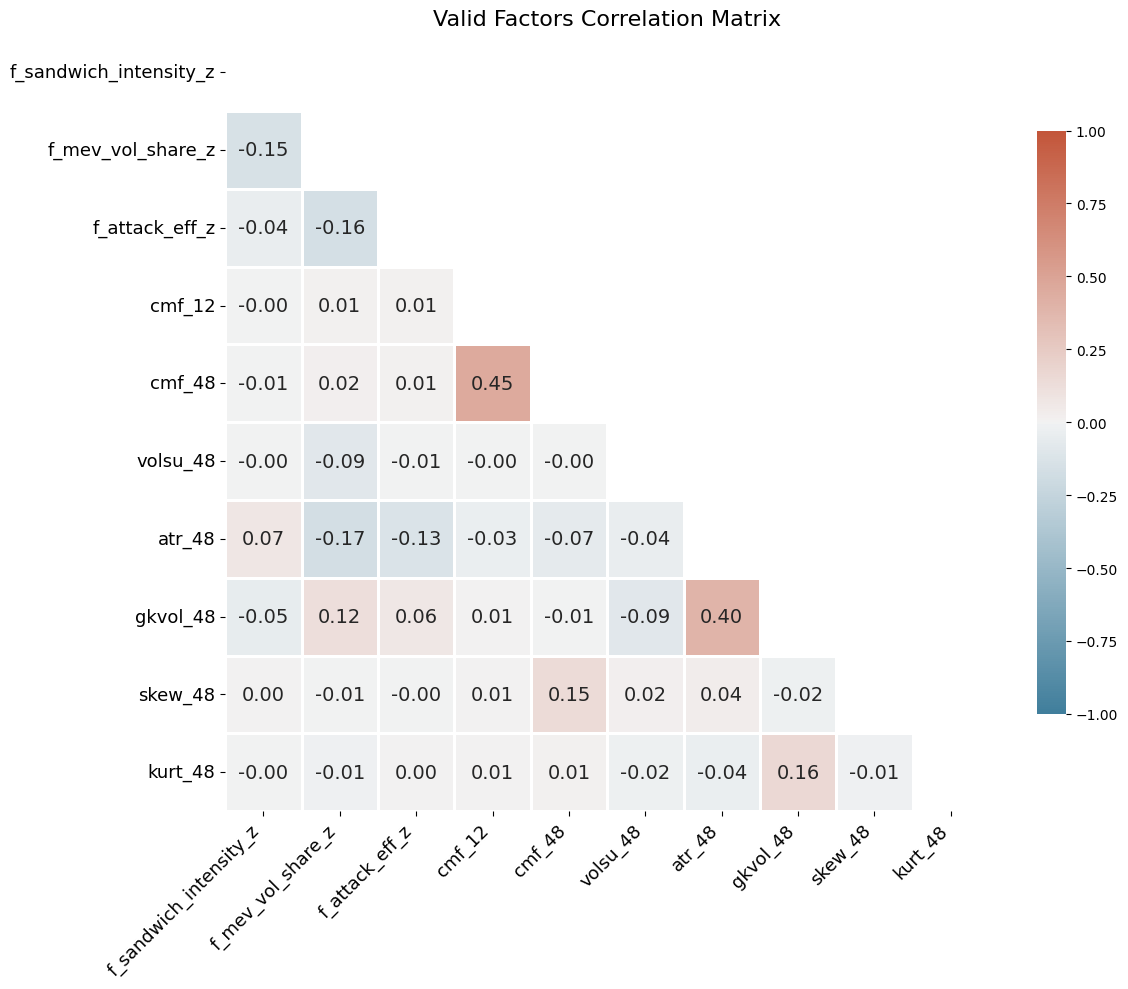

In [59]:
plot_factor_correlation_matrix(factors[final_factors], method='spearman', title="Valid Factors Correlation Matrix")

## 3. 因子组合

In [52]:
print(ic_series[final_factors])

f_sandwich_intensity_z    0.103527
f_mev_vol_share_z        -0.273309
f_attack_eff_z           -0.186108
cmf_12                   -0.033270
cmf_48                   -0.059535
volsu_48                 -0.025544
atr_48                    0.796816
gkvol_48                 -0.178434
skew_48                   0.043461
kurt_48                  -0.070537
dtype: float64


In [ ]:
# OU曲线


In [ ]:
# 最终因子加权合成信号
df_final = factors[final_factors]
signal = pd.Series(0, index=df_final.index)
for factor in final_factors:
    # 因子标准化（Z-score）
    df_std = (df_final[factor] - df_final[factor].rolling(window=144).mean()) / df_final[factor].rolling(window=144).std()
    # 因子加权，权重为 IC 值
    alpha = ic_series[factor] * df_std
    # 因子得分累加
    signal += alpha

# 对信号进行标准化
signal = (signal - signal.rolling(window=144).mean()) / signal.rolling(window=144).std()
signal.name = "signal"

In [44]:
print(signal.head(5))
df = pd.concat([market['close'], signal], axis=1, join='inner')
print(df.tail(5))

2019-01-01 00:00:00   NaN
2019-01-01 00:05:00   NaN
2019-01-01 00:10:00   NaN
2019-01-01 00:15:00   NaN
2019-01-01 00:20:00   NaN
Name: signal, dtype: float64
                            close    signal
2026-01-31 23:35:00  78909.390625 -0.202374
2026-01-31 23:40:00  78839.359375  2.003527
2026-01-31 23:45:00  78739.531250  1.812476
2026-01-31 23:50:00  78753.359375  1.839141
2026-01-31 23:55:00  78741.093750  1.897297


In [50]:
ic_signal = df['signal'].corr(df['close'].vbt.returns().obj.shift(-1), method='spearman')
print(f"Signal Rank IC: {ic_signal:.6f}")

Signal Rank IC: 0.007226


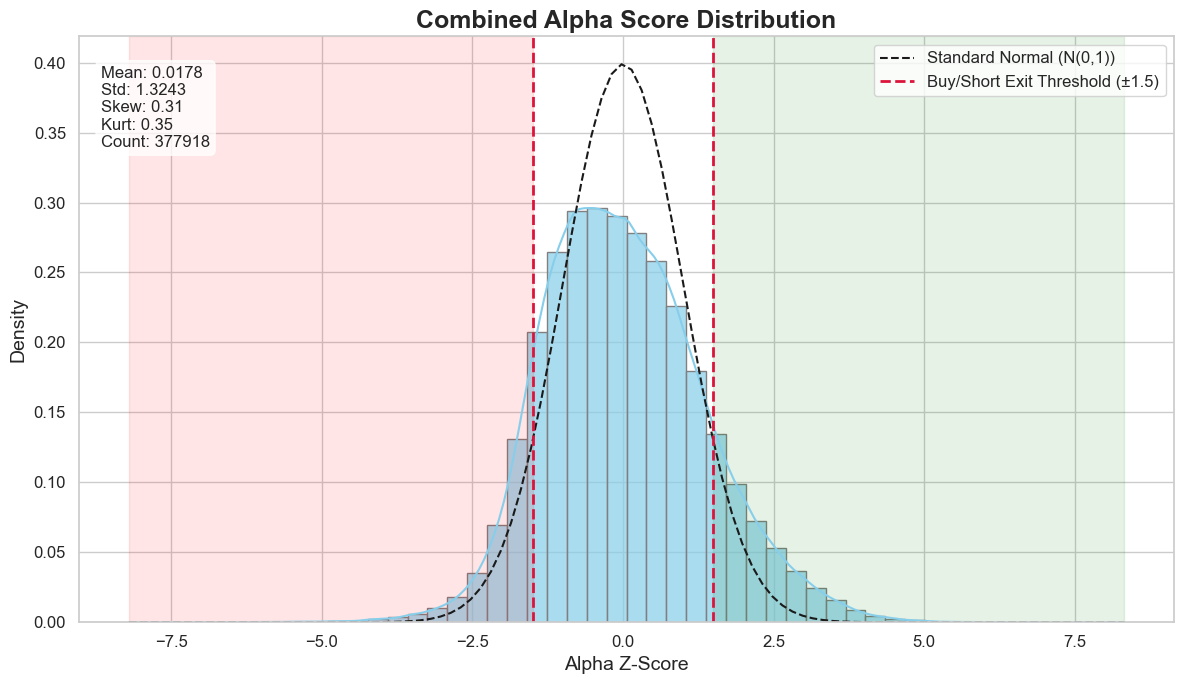

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def plot_signal_distribution(signal_series, threshold=1.5, title="Combined Alpha Score Distribution"):
    """
    绘制合成信号的分布图，包含 KDE 和阈值线。
    
    参数:
    ----------
    signal_series : pd.Series
        合成后的 Z-Score 信号序列。
    threshold : float
        交易触发的绝对值阈值。
    title : str
        图像标题。
    """
    # 处理缺失值（滚动计算初期会有 NaN）
    clean_signal = signal_series.dropna()
    
    # 1. 设置绘图风格
    sns.set_theme(style="whitegrid", palette="pastel")
    
    # 2. 创建画布
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # 3. 绘制直方图和 KDE 曲线
    # stat="density" 确保纵轴是密度，方便与正态分布对比
    sns.histplot(clean_signal, kde=True, stat="density", bins=50, color="skyblue", edgecolor="gray", alpha=0.7, ax=ax)
    
    # 4. 绘制理论正态分布曲线 (N(0,1)) 作为基准
    x = np.linspace(clean_signal.min(), clean_signal.max(), 100)
    p = np.exp(-x**2/2) / np.sqrt(2*np.pi) # 标准正态分布公式
    ax.plot(x, p, 'k--', linewidth=1.5, label='Standard Normal (N(0,1))')

    # 5. 绘制交易阈值红线
    # 多头触发线
    ax.axvline(x=threshold, color='crimson', linestyle='--', linewidth=2, label=f'Buy/Short Exit Threshold (±{threshold})')
    # 空头触发线
    ax.axvline(x=-threshold, color='crimson', linestyle='--', linewidth=2)
    
    # 6. 填充持仓区域（可选，视觉更直观）
    # 填充多头区域
    ax.axvspan(threshold, clean_signal.max(), color='green', alpha=0.1)
    # 填充空头区域
    ax.axvspan(clean_signal.min(), -threshold, color='red', alpha=0.1)

    # 7. 设置标题和标签
    ax.set_title(title, fontsize=18, fontweight='bold')
    ax.set_xlabel("Alpha Z-Score", fontsize=14)
    ax.set_ylabel("Density", fontsize=14)
    ax.tick_params(labelsize=12)
    ax.legend(fontsize=12, loc='upper right')
    
    # 8. 添加统计信息文本框
    stats_text = (
        f"Mean: {clean_signal.mean():.4f}\n"
        f"Std: {clean_signal.std():.4f}\n"
        f"Skew: {clean_signal.skew():.2f}\n"
        f"Kurt: {clean_signal.kurt():.2f}\n"
        f"Count: {len(clean_signal)}"
    )
    # 将文本框放在左上角
    props = dict(boxstyle='round', facecolor='white', alpha=0.8)
    ax.text(0.02, 0.95, stats_text, transform=ax.transAxes, fontsize=12,
            verticalalignment='top', bbox=props)

    plt.tight_layout()
    plt.show()



plot_signal_distribution(signal, threshold=1.5)

In [46]:
import vectorbt as vbt

def run_vbt_backtest(price_series, final_signal_score, threshold=4):
    # 1. 定义信号：超过阈值开多，低于负阈值开空
    # entries: 买入信号 (Score > 1.5)
    # exits: 平多信号 (Score 回落到 0 附近)
    entries = final_signal_score > threshold
    exits = final_signal_score <= 2
    
    # short_entries: 卖出开空信号 (Score < -1.5)
    # short_exits: 平空信号 (Score 回升到 0 附近)
    short_entries = final_signal_score < -threshold
    short_exits = final_signal_score >= -2

    # 2. 构建组合对象
    # freq='5T' 代表 5 分钟数据
    pf = vbt.Portfolio.from_signals(
        close=price_series, 
        entries=entries, 
        exits=exits, 
        short_entries=short_entries, 
        short_exits=short_exits,
        fees=0.0006,     # 交易手续费（千分之0.6）
        slippage=0.0001, # 模拟滑点
        init_cash=10000,
        freq='5min'
    )

    # 3. 关键：画出回测综合曲线
    # 这会生成一个包含：净值(Value)、回撤(Drawdown)、订单(Orders)的交互式图表
    #pf.plot().show()
    
    # 4. 打印统计报告（夏普、胜率、最大回撤等）
    print(pf.stats())

    # 计算基准收益（买入并持有）
    #fig = pf.value().vbt.plot(name='My Strategy')
    #benchmark_pf = vbt.Portfolio.from_holding(price_series, init_cash=10000)
    #benchmark_pf.value().vbt.plot(fig=fig, name='Buy & Hold')
    #fig.show()
    return pf



In [47]:
# 调用执行
pf_result = run_vbt_backtest(df['close'], df['signal'])

Start                               2019-01-01 00:00:00
End                                 2026-01-31 23:55:00
Period                               2584 days 21:10:00
Start Value                                     10000.0
End Value                                    464.230997
Total Return [%]                              -95.35769
Benchmark Return [%]                        2030.256462
Max Gross Exposure [%]                            100.0
Total Fees Paid                             8167.419959
Max Drawdown [%]                              95.757403
Max Drawdown Duration                1891 days 10:25:00
Total Trades                                       2146
Total Closed Trades                                2146
Total Open Trades                                     0
Open Trade PnL                                      0.0
Win Rate [%]                                  13.653308
Best Trade [%]                                 7.630003
Worst Trade [%]                              -15

In [7]:
final_factors_without_atr = [f for f in final_factors if 'atr_48' not in f]

NameError: name 'final_factors' is not defined

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_significant_ic_moments(df_factors, target_returns, window, threshold):
    """
    捕捉并绘制因子进入“有效区间”的瞬间
    """
    # 1. 计算滚动 IC
    rolling_ic = pd.DataFrame(index=df_factors.index)
    for col in df_factors.columns:
        rolling_ic[col] = df_factors[col].rolling(window=window, min_periods=int(window*0.8)).corr(target_returns)
    
    # 2. 绘图
    plt.figure(figsize=(15, 8))
    
    # 为了清晰，我们只选总 IC 最强的几个因子画图，否则线太多
    # 这里假设你传入的就是你表里的那几个
    for col in rolling_ic.columns:
        series = rolling_ic[col]
        
        # 绘制背景淡色曲线
        plt.plot(series.index, series, label=f'{col} (full)', alpha=0.3, linewidth=0.8)
        
        # 【关键】捕捉并高亮超过阈值的点
        # 我们只保留绝对值大于 threshold 的部分，其余设为 NaN
        sig_moments = series.where(series.abs() > threshold)
        plt.scatter(sig_moments.index, sig_moments, s=2, label=f'{col} > {threshold}', marker='o')

    # 绘制阈值线
    plt.axhline(y=threshold, color='red', linestyle='--', alpha=0.6)
    plt.axhline(y=-threshold, color='red', linestyle='--', alpha=0.6)
    plt.axhline(y=0, color='black', linewidth=1)

    plt.title(f"Moments where Rolling IC > {threshold} (Window={window})", fontsize=14)
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()

    # 3. 统计：计算每个因子处于“有效状态”的时间占比
    active_ratio = (rolling_ic.abs() > threshold).mean()
    print("--- 因子进入‘有效状态’的时间占比 ---")
    print(active_ratio.sort_values(ascending=False))
    
    return rolling_ic

rolling_ic = plot_significant_ic_moments(factors[final_factors_without_atr], market["close"].pct_change().shift(-1), window=144, threshold=0.16)

NameError: name 'final_factors_without_atr' is not defined

In [14]:
df= factors
window = 144
target_returns = market["close"].pct_change().shift(-1)

rolling_ic = pd.DataFrame(index=df.index)
for col in df.columns:
    rolling_ic[col] = df[col].rolling(window=window, min_periods=int(window*0.8)).corr(target_returns)

import pandas as pd
import numpy as np

# 设定有效性阈值，例如 IC > 0.02 认为因子在该时刻有效
threshold = 0.1
is_effective = rolling_ic.abs() > threshold

def count_continuous_periods(series):
    # 核心逻辑：
    # 1. 找出变化点 (series != series.shift())
    # 2. 通过 cumsum() 给每一段连续的相同值分配一个唯一 ID
    # 3. 在每个 ID 组内进行累加
    groups = (series != series.shift()).cumsum()
    return series.groupby(groups).cumsum()

# 应用到所有列
continuous_effective_days = is_effective.apply(count_continuous_periods)

In [18]:
print(continuous_effective_days.describe())

       f_sandwich_intensity_z  f_mev_vol_share_z  f_attack_eff_z  \
count           745326.000000      745326.000000   745326.000000   
mean                 5.087822           3.883379        4.615765   
std                 19.801190          17.121067       18.935633   
min                  0.000000           0.000000        0.000000   
25%                  0.000000           0.000000        0.000000   
50%                  0.000000           0.000000        0.000000   
75%                  0.000000           0.000000        0.000000   
max                327.000000         307.000000      385.000000   

               roc_6         roc_12         roc_48        madev_6  \
count  745326.000000  745326.000000  745326.000000  745326.000000   
mean       21.884828      19.077005      19.645618      25.671605   
std        48.758959      42.611943      42.962473      56.112623   
min         0.000000       0.000000       0.000000       0.000000   
25%         0.000000       0.000000       